# Retrain All-in-One: SVM + BiLSTM + IndoBERTweet -> Ensemble

## 1. Install dependencies

In [ ]:
!pip install emoji Sastrawi openpyxl gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 54.8 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import re
import html
import numpy as np
import pandas as pd
import emoji
import joblib

import torch
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from torch.utils.data import Dataset

from gensim.models import Word2Vec
from sklearn.svm import SVC

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Bidirectional, LSTM, Dense, Dropout, Input, Attention,
    GlobalAveragePooling1D, GlobalMaxPooling1D, Concatenate,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

## 3. Upload dataset & download kamus slang
Upload `balanced_dataset.xlsx` (atau nama dataset kamu) ke session Colab (drag-drop
ke panel File di kiri), lalu jalankan cell di bawah.

In [ ]:
!wget -q https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv -O /content/kamus_alay.csv

## 4. Konfigurasi

In [ ]:
DATA_PATH_MAIN = '/content/balanced_dataset.xlsx'
DATA_PATH_TEST = '/content/id-text-label.csv'
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'
SLANGDICT_PATH = '/content/kamus_alay.csv'

BERT_BASE_MODEL_NAME = "indolem/indobertweet-base-uncased"

RANDOM_STATE = 42
N_TEST_SAMPLES = 450
VAL_SIZE = 0.1

MAX_SEQUENCE_LENGTH = 50
HIDDEN_SIZE = 768
BATCH_SIZE_EXTRACTION = 16

# --- Word2Vec + SVM ---
W2V_VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_SG = 1
W2V_EPOCHS = 50
SVM_C = 10.0

# --- BiLSTM + Attention ---
LSTM_UNITS = 64     # tadinya 128
DENSE_UNITS = 32     # tadinya 64
RECURRENT_DROPOUT = 0.4    # tadinya 0.2
DROPOUT_RATE = 0.5         # tadinya 0.3
BILSTM_LEARNING_RATE = 0.003 # tadinya 0.001
BILSTM_BATCH_SIZE = 32
BILSTM_EPOCHS = 30
USE_CLASS_WEIGHT_BILSTM = True

# --- Fine-tuned IndoBERTweet ---
FT_LEARNING_RATE = 2e-5
FT_BATCH_SIZE = 16
FT_EPOCHS = 10
FT_WEIGHT_DECAY = 0.01
USE_CLASS_WEIGHT_FT = True
FT_OUTPUT_DIR = "./indobertweet_finetuned"

# --- Ensemble ---
MODEL_WEIGHTS = {"svm": 1.0, "bilstm": 1.0, "indobertweet": 1.0}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 4b. Seeding menyeluruh (WAJIB untuk reproducibility BiLSTM & fine-tuning)


In [ ]:
import os
import random

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

import tensorflow as tf
tf.random.set_seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

try:
    tf.config.experimental.enable_op_determinism()
except AttributeError:
    print("tf.config.experimental.enable_op_determinism() tidak tersedia di versi TF ini -- skip.")

print("Semua random seed sudah di-set.")

Semua random seed sudah di-set.


## 5. Load data
- dari 4500 diambil 10% utk validation dari balanced_dataset, sisanya training
- dari id_text_label diambil dengan jumlah yang sama kayak validation untuk test (karena id_text_label data aslinya)

In [ ]:
df_main = pd.read_excel(DATA_PATH_MAIN)
df_main = df_main.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).reset_index(drop=True)
df_main[TEXT_COLUMN] = df_main[TEXT_COLUMN].astype(str)

df_test_source = pd.read_csv(DATA_PATH_TEST)
df_test_source = df_test_source.dropna(subset=['Text', 'Label']).reset_index(drop=True)
df_test_source['Text'] = df_test_source['Text'].astype(str)

overlap = set(df_main[TEXT_COLUMN]) & set(df_test_source['Text'])
if len(overlap) > 0:
    print(f"PERINGATAN: ditemukan {len(overlap)} teks yang identik di kedua file -- ini bisa bikin data leakage!")
else:
    print("Tidak ada teks yang identik persis di antara kedua file. Aman.")

label_encoder = LabelEncoder()
all_labels = pd.concat([df_main[LABEL_COLUMN], df_test_source['Label']], ignore_index=True)
label_encoder.fit(all_labels)
print("Mapping label:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

df_main["label_encoded"] = label_encoder.transform(df_main[LABEL_COLUMN])
df_test_source["label_encoded"] = label_encoder.transform(df_test_source['Label'])
num_classes = df_main["label_encoded"].nunique()

train_df, val_df = train_test_split(
    df_main, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=df_main["label_encoded"],
)

test_df, _ = train_test_split(
    df_test_source, train_size=N_TEST_SAMPLES, random_state=RANDOM_STATE,
    stratify=df_test_source["label_encoded"],
)

texts_train = train_df[TEXT_COLUMN].tolist()
y_train = train_df["label_encoded"].values

texts_val = val_df[TEXT_COLUMN].tolist()
y_val = val_df["label_encoded"].values

texts_test = test_df['Text'].tolist()
y_test = test_df["label_encoded"].values

print(f"train: {len(texts_train)}, val: {len(texts_val)}, test: {len(texts_test)}")

PERINGATAN: ditemukan 3027 teks yang identik di kedua file -- ini bisa bikin data leakage!
Mapping label: {'Benevolent Misogyny': np.int64(0), 'Hostile Misogyny': np.int64(1), 'Non-Misogyny': np.int64(2)}
train: 4050, val: 450, test: 450


## 6. Fungsi evaluasi (dipakai semua model)

In [ ]:
def evaluate(y_true, y_pred, set_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    print(f"\n{'='*60}\n{set_name}\n{'='*60}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

# MODEL 1 -- SVM + Word2Vec
## 7. Preprocessing Jalur A (berat: stemming, stopword removal, tetap keep negasi)

In [ ]:
slang_df_svm = pd.read_csv(SLANGDICT_PATH)
slang_dict_svm = dict(zip(slang_df_svm["slang"], slang_df_svm["formal"]))

_stemmer = StemmerFactory().create_stemmer()
_stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
NEGATION_WORDS = {"tidak", "bukan", "jangan", "tanpa", "belum"}


def clean_html_entity(text):
    return html.unescape(text)


def handle_emoji_svm(text):
    text = emoji.demojize(text, language="en")
    text = re.sub(r":(\w+):", r"[\1]", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_elongation_svm(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)


def normalize_slang_svm(text, slang_dict=slang_dict_svm):
    words = text.split()
    normalized_words = [slang_dict.get(word.lower(), word) for word in words]
    return " ".join(normalized_words)


def remove_stopword_keep_negation(text):
    words = text.split()
    kept = []
    for w in words:
        if w in NEGATION_WORDS:
            kept.append(w)
        else:
            cleaned = _stopword_remover.remove(w)
            if cleaned.strip():
                kept.append(cleaned)
    return " ".join(kept)


def clean_all_svm(text):
    text = clean_html_entity(text)
    text = re.sub(r"&amp;", "&", text)
    text = re.sub(r"&lt;", "<", text)
    text = re.sub(r"&gt;", ">", text)
    text = re.sub(r"&quot;", '"', text)
    text = normalize_elongation_svm(text)
    text = handle_emoji_svm(text)
    text = normalize_slang_svm(text)
    return text


def preprocess_word2vec(text):
    text = text.lower()
    text = remove_stopword_keep_negation(text)
    text = _stemmer.stem(text)
    return text.split()


def vectorize_sentence(tokens, w2vmodel):
    vectors = [w2vmodel.wv[token] for token in tokens if token in w2vmodel.wv]
    if len(vectors) == 0:
        return np.zeros(w2vmodel.vector_size)
    return np.mean(vectors, axis=0)


def build_feature_matrix(tokenized, w2vmodel):
    return np.array([vectorize_sentence(tokens, w2vmodel) for tokens in tokenized])

## 8. Terapkan preprocessing ke train/val/test

In [ ]:
# tokens_train_svm = [preprocess_word2vec(clean_all_svm(t)) for t in texts_train]
# tokens_val_svm = [preprocess_word2vec(clean_all_svm(t)) for t in texts_val]
# tokens_test_svm = [preprocess_word2vec(clean_all_svm(t)) for t in texts_test]

# # buang baris kosong HANYA di train
# train_mask_svm = [len(toks) > 0 for toks in tokens_train_svm]
# tokens_train_svm = [t for t, m in zip(tokens_train_svm, train_mask_svm) if m]
# ytrain_svm = y_train[np.array(train_mask_svm)]

# yval_svm = y_val
# ytest_svm = y_test

# print(f"train (setelah buang kosong): {len(tokens_train_svm)}, val: {len(tokens_val_svm)}, test: {len(tokens_test_svm)}")

KeyboardInterrupt: 

In [ ]:
from multiprocessing import Pool

def _initialize_stemmer_and_remover():
    global _stemmer, _stopword_remover, slang_dict_svm
    _stemmer = StemmerFactory().create_stemmer()
    _stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
    slang_df_svm = pd.read_csv(SLANGDICT_PATH)
    slang_dict_svm = dict(zip(slang_df_svm["slang"], slang_df_svm["formal"]))

def _preprocess_single_text(text):
    return preprocess_word2vec(clean_all_svm(text))

print("Starting parallel preprocessing...")
with Pool(initializer=_initialize_stemmer_and_remover) as p:
    tokens_train_svm = p.map(_preprocess_single_text, texts_train)
    tokens_val_svm = p.map(_preprocess_single_text, texts_val)
    tokens_test_svm = p.map(_preprocess_single_text, texts_test)
print("Parallel preprocessing finished.")

# buang baris kosong HANYA di train
train_mask_svm = [len(toks) > 0 for toks in tokens_train_svm]
tokens_train_svm = [t for t, m in zip(tokens_train_svm, train_mask_svm) if m]
ytrain_svm = y_train[np.array(train_mask_svm)]

yval_svm = y_val
ytest_svm = y_test

print(f"train (setelah buang kosong): {len(tokens_train_svm)}, val: {len(tokens_val_svm)}, test: {len(tokens_test_svm)}")

Starting parallel preprocessing...
Parallel preprocessing finished.
train (setelah buang kosong): 4050, val: 450, test: 450


## 9. Training Word2Vec (HANYA dari train) + SVM

In [ ]:
w2v_model = Word2Vec(
    sentences=tokens_train_svm,
    vector_size=W2V_VECTOR_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    sg=W2V_SG,
    epochs=W2V_EPOCHS,
    seed=RANDOM_STATE,
    workers=1,  # workers>1 bikin urutan update antar-thread tidak deterministik meski sudah ada seed
)

In [ ]:
X_train_svm = build_feature_matrix(tokens_train_svm, w2v_model)
X_val_svm = build_feature_matrix(tokens_val_svm, w2v_model)
X_test_svm = build_feature_matrix(tokens_test_svm, w2v_model)

In [ ]:
svm_model = SVC(kernel="rbf", C=SVM_C, gamma="scale", probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_svm, ytrain_svm)

In [ ]:
print("Validation:")
evaluate(yval_svm, svm_model.predict(X_val_svm), "SVM - Validation")
print("Test:")
evaluate(ytest_svm, svm_model.predict(X_test_svm), "SVM - Test")

Validation:

SVM - Validation
Accuracy  : 0.8222
Precision : 0.8289
Recall    : 0.8222
F1-score  : 0.8228

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       150
           1       0.86      0.73      0.79       150
           2       0.71      0.81      0.76       150

    accuracy                           0.82       450
   macro avg       0.83      0.82      0.82       450
weighted avg       0.83      0.82      0.82       450

Confusion Matrix:
[[138   0  12]
 [  3 110  37]
 [ 10  18 122]]
Test:

SVM - Test
Accuracy  : 0.8622
Precision : 0.8824
Recall    : 0.8622
F1-score  : 0.8671

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.92      0.78        36
           1       0.70      0.86      0.77        88
           2       0.96      0.86      0.90       326

    accuracy                           0.86       450
   macro avg       0.78      0.88  

{'accuracy': 0.8622222222222222,
 'precision': 0.8824199944315207,
 'recall': 0.8622222222222222,
 'f1': 0.8671131842154174}

# MODEL 2 -- BiLSTM + Attention (di atas embedding IndoBERTweet)
## 10. Preprocessing Jalur B (ringan: tanpa stemming/stopword removal, TAPI bersihkan URL/mention)

In [ ]:
slang_df_bert = pd.read_csv(SLANGDICT_PATH)
slang_dict_bert = dict(zip(slang_df_bert["slang"], slang_df_bert["formal"]))


def clean_html_bert(text):
    text = html.unescape(text)
    text = re.sub(r"&amp;", "&", text)
    text = re.sub(r"&lt;", "<", text)
    text = re.sub(r"&gt;", ">", text)
    text = re.sub(r"&quot;", '"', text)
    return text


def handle_emoji_bert(text):
    text = emoji.demojize(text, language="en")
    text = re.sub(r":(\w+):", r"[\1]", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_clean_bert(text):
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_elongation_bert(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)


def normalize_slang_bert(text, slangdict=slang_dict_bert):
    tokens = text.split()
    normalized = [slangdict.get(t.lower(), t) for t in tokens]
    return " ".join(normalized)


def preprocesstext_bert(text, slangdict=slang_dict_bert):
    text = clean_html_bert(text)
    text = handle_emoji_bert(text)
    text = clean_clean_bert(text)
    text = normalize_elongation_bert(text)
    text = normalize_slang_bert(text, slangdict)
    return text

In [ ]:
cleantext_train = [preprocesstext_bert(t) for t in texts_train]
cleantext_val = [preprocesstext_bert(t) for t in texts_val]
cleantext_test = [preprocesstext_bert(t) for t in texts_test]

In [ ]:
# jalur B jauh lebih jarang menghasilkan teks kosong, tapi tetap dicek untuk berjaga-jaga
train_mask_bert = [len(t.strip()) > 0 for t in cleantext_train]
cleantext_train_bilstm = [t for t, m in zip(cleantext_train, train_mask_bert) if m]
ytrain_bilstm = y_train[np.array(train_mask_bert)]

In [ ]:
cleantext_val_bilstm = cleantext_val
cleantext_test_bilstm = cleantext_test
yval_bilstm = y_val
ytest_bilstm = y_test

## 11. Ekstraksi embedding IndoBERTweet (frozen, feature extractor)

In [ ]:
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_BASE_MODEL_NAME)
bert_base_model = AutoModel.from_pretrained(BERT_BASE_MODEL_NAME).to(DEVICE)
bert_base_model.eval()


def extract_bert_embeddings(texts, tokenizer, model, batch_size=16):
    all_embeddings = []
    all_attention_masks = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts, padding="max_length", truncation=True,
                max_length=MAX_SEQUENCE_LENGTH, return_tensors="pt",
            ).to(DEVICE)
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state.cpu().numpy()
            attention_masks = inputs['attention_mask'].cpu().numpy()
            all_embeddings.append(embeddings)
            all_attention_masks.append(attention_masks)
            if (i // batch_size) % 10 == 0:
                print(f"embedding extraction: {i + len(batch_texts)}/{len(texts)}")

    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_embeddings_masks = np.concatenate(all_embeddings_masks, axis=0)
    return np.concatenate(all_embeddings, axis=0)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def extract_bert_embeddings(texts, tokenizer, model, batch_size=16):
    all_embeddings = []
    all_attention_masks = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts, padding="max_length", truncation=True,
                max_length=MAX_SEQUENCE_LENGTH, return_tensors="pt",
            ).to(DEVICE)
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state.cpu().numpy()
            attention_masks = inputs['attention_mask'].cpu().numpy()
            all_embeddings.append(embeddings)
            all_attention_masks.append(attention_masks)
            if (i // batch_size) % 10 == 0:
                print(f"embedding extraction: {i + len(batch_texts)}/{len(texts)}")

    concatenated_embeddings = np.concatenate(all_embeddings, axis=0)
    # Corrected: use all_attention_masks
    concatenated_attention_masks = np.concatenate(all_attention_masks, axis=0)

    # Corrected: return both embeddings and attention masks
    return concatenated_embeddings, concatenated_attention_masks

X_train_bilstm, mask_train_bilstm = extract_bert_embeddings(cleantext_train_bilstm, bert_tokenizer, bert_base_model, BATCH_SIZE_EXTRACTION)
X_val_bilstm, mask_val_bilstm = extract_bert_embeddings(cleantext_val_bilstm, bert_tokenizer, bert_base_model, BATCH_SIZE_EXTRACTION)
X_test_bilstm, mask_test_bilstm = extract_bert_embeddings(cleantext_test_bilstm, bert_tokenizer, bert_base_model, BATCH_SIZE_EXTRACTION)

embedding extraction: 16/4050
embedding extraction: 176/4050
embedding extraction: 336/4050
embedding extraction: 496/4050
embedding extraction: 656/4050
embedding extraction: 816/4050
embedding extraction: 976/4050
embedding extraction: 1136/4050
embedding extraction: 1296/4050
embedding extraction: 1456/4050
embedding extraction: 1616/4050
embedding extraction: 1776/4050
embedding extraction: 1936/4050
embedding extraction: 2096/4050
embedding extraction: 2256/4050
embedding extraction: 2416/4050
embedding extraction: 2576/4050
embedding extraction: 2736/4050
embedding extraction: 2896/4050
embedding extraction: 3056/4050
embedding extraction: 3216/4050
embedding extraction: 3376/4050
embedding extraction: 3536/4050
embedding extraction: 3696/4050
embedding extraction: 3856/4050
embedding extraction: 4016/4050
embedding extraction: 16/450
embedding extraction: 176/450
embedding extraction: 336/450
embedding extraction: 16/450
embedding extraction: 176/450
embedding extraction: 336/45

In [ ]:
print("Train embeddings :", X_train_bilstm.shape)
print("Train mask       :", mask_train_bilstm.shape)

print("Val embeddings   :", X_val_bilstm.shape)
print("Val mask         :", mask_val_bilstm.shape)

print("Test embeddings  :", X_test_bilstm.shape)
print("Test mask        :", mask_test_bilstm.shape)

## 12. Build & training BiLSTM + Attention

In [ ]:
from tensorflow.keras.regularizers import l2

def build_bilstm_attention_model(num_classes):
    is_binary = num_classes == 2
    inputs = Input(shape=(MAX_SEQUENCE_LENGTH, HIDDEN_SIZE), name="indobertweet_embedding_input")

    lstm_out = Bidirectional(
        # tadinya LSTM(LSTM_UNITS, recurrent_dropout=RECURRENT_DROPOUT, return_sequences=True)
        LSTM(LSTM_UNITS, recurrent_dropout=RECURRENT_DROPOUT, return_sequences=True, kernel_regularizer=l2(0.01))
    )(
        embeddings_input,
        mask=attention_mask_input
    )
    lstm_out = Dropout(DROPOUT_RATE)(lstm_out)
    attn_out = Attention(name="self_attention")(
        [lstm_out, lstm_out],
        mask = [attention_mask_input, attention_mask_input]
    )
    avg_pool = tf.keras.layers.Lambda(
        lambda tensors: masked_average_pooling(tensors[0], tensors[1]),
        name="masked_average_pooling"
    )([attn_out, attention_mask_input])
    max_pool = tf.keras.layers.Lambda(
        lambda tensors: masked_max_pooling(tensors[0], tensors[1]),
        name="masked_max_pooling"
    )([attn_out, attention_mask_input])
    pooled = Concatenate(name="combined_pooling")([avg_pool, max_pool])

    # tadinya x = Dense(DENSE_UNITS, activation="relu")(pooled)
    x = Dense(DENSE_UNITS, activation="relu", kernel_regularizer=l2(0.01))(pooled)
    x = Dropout(DROPOUT_RATE)(x)

    if is_binary:
        outputs = Dense(1, activation="sigmoid", name="output")(x)
        loss = "binary_crossentropy"
    else:
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        loss = "sparse_categorical_crossentropy"

    model = Model(inputs=[embedding_input, attention_mask_input], outputs=outputs, name="BiLSTM_Attention_Masked")
    model.compile(optimizer=Adam(learning_rate=BILSTM_LEARNING_RATE), loss=loss, metrics=["accuracy"])
    model.summary()
    return model

In [ ]:
class_weight_bilstm = None
if USE_CLASS_WEIGHT_BILSTM:
    classes = np.unique(ytrain_bilstm)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=ytrain_bilstm)
    class_weight_bilstm = dict(zip(classes, weights))
    print(f"class weights: {class_weight_bilstm}")

class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}


In [ ]:
from tensorflow.keras.regularizers import l2

def build_bilstm_attention_model(num_classes):
    is_binary = num_classes == 2
    # Corrected: Define embedding_input and attention_mask_input as Input layers
    embedding_input = Input(shape=(MAX_SEQUENCE_LENGTH, HIDDEN_SIZE), name="indobertweet_embedding_input")
    attention_mask_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32', name="indobertweet_attention_mask_input")

    lstm_out = Bidirectional(
        LSTM(LSTM_UNITS, recurrent_dropout=RECURRENT_DROPOUT, return_sequences=True, kernel_regularizer=l2(0.01))
    )(
        embedding_input,
        mask=attention_mask_input
    )
    lstm_out = Dropout(DROPOUT_RATE)(lstm_out)
    attn_out = Attention(name="self_attention")(
        [lstm_out, lstm_out],
        mask = [attention_mask_input, attention_mask_input]
    )

    # Helper functions for masked pooling (assuming they are defined elsewhere or will be added)
    def masked_average_pooling(x, mask):
        mask = tf.cast(tf.expand_dims(mask, -1), tf.float32)
        masked_output = x * mask
        sum_masked = tf.reduce_sum(masked_output, axis=1)
        num_elements = tf.reduce_sum(mask, axis=1)
        return sum_masked / (num_elements + 1e-8) # Add epsilon to avoid division by zero

    def masked_max_pooling(x, mask):
        mask = tf.cast(tf.expand_dims(mask, -1), tf.float32)
        # Set masked values to a very small number so they don't affect max pooling
        masked_output = x + (1.0 - mask) * tf.float32.min
        return tf.reduce_max(masked_output, axis=1)

    avg_pool = tf.keras.layers.Lambda(
        lambda tensors: masked_average_pooling(tensors[0], tensors[1]),
        name="masked_average_pooling"
    )([attn_out, attention_mask_input])
    max_pool = tf.keras.layers.Lambda(
        lambda tensors: masked_max_pooling(tensors[0], tensors[1]),
        name="masked_max_pooling"
    )([attn_out, attention_mask_input])
    pooled = Concatenate(name="combined_pooling")([avg_pool, max_pool])

    x = Dense(DENSE_UNITS, activation="relu", kernel_regularizer=l2(0.01))(pooled)
    x = Dropout(DROPOUT_RATE)(x)

    if is_binary:
        outputs = Dense(1, activation="sigmoid", name="output")(x)
        loss = "binary_crossentropy"
    else:
        outputs = Dense(num_classes, activation="softmax", name="output")(x)
        loss = "sparse_categorical_crossentropy"

    model = Model(inputs=[embedding_input, attention_mask_input], outputs=outputs, name="BiLSTM_Attention_Masked")
    model.compile(optimizer=Adam(learning_rate=BILSTM_LEARNING_RATE), loss=loss, metrics=["accuracy"])
    model.summary()
    return model

bilstm_model = build_bilstm_attention_model(num_classes)
early_stop_bilstm = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'masked_average_pooling' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'masked_max_pooling' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "BiLSTM_Attention_Masked"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ indobertweet_embed… │ (None, 50, 768)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ indobertweet_atten… │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 50, 128)   │    426,496 │ indobertweet_emb… │
│ (Bidirectional)     │                   │            │ indobertweet_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 50, 128)   │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 50, 128)   │          0 │ dropout_4[0][0],  │
│ (Attention)         │                   │            │ dropout_4[0][0],  │
│                     │                   │            │ indobertweet_att… │
│                     │                   │            │ indobertweet_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_average_poo… │ (None, 128)       │          0 │ self_attention[0… │
│ (Lambda)            │                   │            │ indobertweet_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masked_max_pooling  │ (None, 128)       │          0 │ self_attention[0… │
│ (Lambda)            │                   │            │ indobertweet_att… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_pooling    │ (None, 256)       │          0 │ masked_average_p… │
│ (Concatenate)       │                   │            │ masked_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      8,224 │ combined_pooling… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         99 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 434,819 (1.66 MB)

 Trainable params: 434,819 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

bilstm_history = bilstm_model.fit(
    x=[X_train_bilstm, mask_train_bilstm.astype(bool)],
    y=ytrain_bilstm,
    validation_data=([X_val_bilstm, mask_val_bilstm.astype(bool)], yval_bilstm),
    batch_size=BILSTM_BATCH_SIZE,
    epochs=BILSTM_EPOCHS,
    class_weight=class_weight_bilstm,
    callbacks=[early_stop_bilstm, ModelCheckpoint('best_bilstm.keras', monitor='val_loss', save_best_only=True)],
    verbose=1,
)

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'masked_average_pooling' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'masked_max_pooling' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


127/127 ━━━━━━━━━━━━━━━━━━━━ 69s 445ms/step - accuracy: 0.5160 - loss: 2.2744 - val_accuracy: 0.6156 - val_loss: 1.1020
Epoch 2/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 72s 367ms/step - accuracy: 0.5879 - loss: 1.1085 - val_accuracy: 0.4733 - val_loss: 1.1934
Epoch 3/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 371ms/step - accuracy: 0.6005 - loss: 1.0317 - val_accuracy: 0.5578 - val_loss: 1.0955
Epoch 4/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 46s 366ms/step - accuracy: 0.6091 - loss: 1.0086 - val_accuracy: 0.6178 - val_loss: 1.0475
Epoch 5/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 46s 362ms/step - accuracy: 0.6368 - loss: 0.9952 - val_accuracy: 0.5711 - val_loss: 1.1168
Epoch 6/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 81s 357ms/step - accuracy: 0.6459 - loss: 0.9999 - val_accuracy: 0.5667 - val_loss: 1.0583
Epoch 7/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 45s 358ms/step - accuracy: 0.6667 - loss: 0.9539 - val_accuracy: 0.6956 - val_loss: 1.0454
Epoch 8/30
127/127 ━━━━━━━━━━━━━━━━━━━━ 46s 359ms/step - accuracy: 0.6830 - loss: 0.9478 - val

KeyboardInterrupt: 

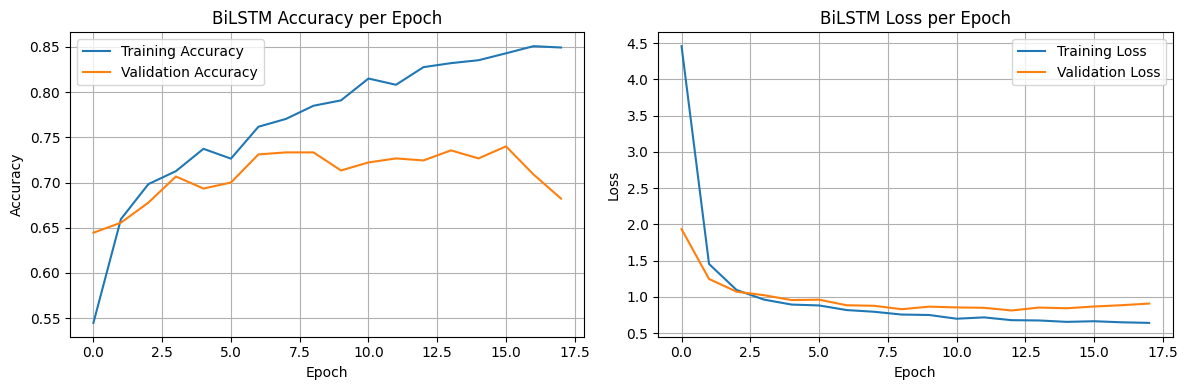

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bilstm_history.history["accuracy"], label="Training Accuracy")
axes[0].plot(bilstm_history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("BiLSTM Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(bilstm_history.history["loss"], label="Training Loss")
axes[1].plot(bilstm_history.history["val_loss"], label="Validation Loss")
axes[1].set_title("BiLSTM Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 13. Evaluasi BiLSTM

In [ ]:
def evaluate_bilstm_probs(model, X, mask, y, num_classes, set_name="Test"):
    is_binary = num_classes == 2
    y_prob = model.predict([X, mask], verbose=0)
    y_pred = (y_prob > 0.5).astype(int).ravel() if is_binary else np.argmax(y_prob, axis=1)
    evaluate(y, y_pred, set_name)
    return y_pred, y_prob

_ = evaluate_bilstm_probs(bilstm_model, X_val_bilstm, mask_val_bilstm.astype(bool), yval_bilstm, num_classes, "BiLSTM - Validation")
_ = evaluate_bilstm_probs(bilstm_model, X_test_bilstm, mask_test_bilstm.astype(bool), ytest_bilstm, num_classes, "BiLSTM - Test")

# for validation
val_probs = bilstm_model.predict([X_val_bilstm, mask_val_bilstm.astype(bool)])
if num_classes == 2:
  val_pred = (val_probs.ravel() >= 0.5).astype(int)
else:
  val_pred = np.argmax(val_probs, axis=1)

# for test
test_probs = bilstm_model.predict([X_test_bilstm, mask_test_bilstm.astype(bool)])
if num_classes == 2:
  test_pred = (test_probs.ravel() >= 0.5).astype(int)
else:
  test_pred = np.argmax(test_probs, axis=1)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'masked_average_pooling' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'masked_max_pooling' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(



BiLSTM - Validation
Accuracy  : 0.7244
Precision : 0.7319
Recall    : 0.7244
F1-score  : 0.7235

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       150
           1       0.81      0.63      0.71       150
           2       0.61      0.67      0.64       150

    accuracy                           0.72       450
   macro avg       0.73      0.72      0.72       450
weighted avg       0.73      0.72      0.72       450

Confusion Matrix:
[[130   3  17]
 [  8  95  47]
 [ 29  20 101]]

BiLSTM - Test
Accuracy  : 0.7822
Precision : 0.8344
Recall    : 0.7822
F1-score  : 0.7966

Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.89      0.56        36
           1       0.71      0.76      0.73        88
           2       0.92      0.78      0.84       326

    accuracy                           0.78       450
   macro avg       0.68      0.81      0.71    

# MODEL 3 -- Fine-tuned IndoBERTweet
## 14. Dataset & Trainer setup (reuse preprocessing Jalur B yang sama seperti BiLSTM)

In [ ]:
class MisogynyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {key: val.squeeze(0) for key, val in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss_fct = torch.nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics_ft(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


# reuse cleantext_train/val/test (Jalur B) yang sama persis dengan BiLSTM di atas --
# TIDAK perlu bersihkan ulang, cukup pakai train_mask_bert yang sama
cleantext_train_ft = cleantext_train_bilstm
cleantext_val_ft = cleantext_val_bilstm
cleantext_test_ft = cleantext_test_bilstm
ytrain_ft = ytrain_bilstm
yval_ft = yval_bilstm
ytest_ft = ytest_bilstm

ft_tokenizer = AutoTokenizer.from_pretrained(BERT_BASE_MODEL_NAME)
trainset_ft = MisogynyDataset(cleantext_train_ft, ytrain_ft, ft_tokenizer, MAX_SEQUENCE_LENGTH)
valset_ft = MisogynyDataset(cleantext_val_ft, yval_ft, ft_tokenizer, MAX_SEQUENCE_LENGTH)
testset_ft = MisogynyDataset(cleantext_test_ft, ytest_ft, ft_tokenizer, MAX_SEQUENCE_LENGTH)

class_weight_tensor_ft = None
if USE_CLASS_WEIGHT_FT:
    classes = np.unique(ytrain_ft)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=ytrain_ft)
    class_weight_tensor_ft = torch.tensor(weights, dtype=torch.float)
    print(f"Class weight: {dict(zip(classes, weights))}")

Class weight: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}


## 15. Fine-tuning IndoBERTweet

In [ ]:
ft_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_BASE_MODEL_NAME, num_labels=num_classes
).to(DEVICE)

training_args = TrainingArguments(
    output_dir=FT_OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    save_total_limit=2,  # cuma simpan 2 checkpoint terakhir selama training -- hemat disk
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=FT_EPOCHS,
    per_device_train_batch_size=FT_BATCH_SIZE,
    per_device_eval_batch_size=FT_BATCH_SIZE,
    learning_rate=FT_LEARNING_RATE,
    weight_decay=FT_WEIGHT_DECAY,
    logging_steps=50,
    report_to="none",
    seed=RANDOM_STATE,
)

trainer = WeightedTrainer(
    class_weights=class_weight_tensor_ft,
    model=ft_model,
    args=training_args,
    train_dataset=trainset_ft,
    eval_dataset=valset_ft,
    compute_metrics=compute_metrics_ft,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobertweet-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.622424,0.596924,0.764444,0.762273,0.764444,0.762785
2,0.351320,0.525571,0.806667,0.804329,0.806667,0.802604
3,0.210152,0.648668,0.815556,0.815448,0.815556,0.809032
4,0.098032,0.603583,0.853333,0.853092,0.853333,0.853091
5,0.046886,0.765785,0.851111,0.849321,0.851111,0.848503
6,0.026362,0.896173,0.851111,0.849451,0.851111,0.849041
7,0.020940,0.849808,0.862222,0.860941,0.862222,0.860982
8,0.013415,0.915537,0.848889,0.846884,0.848889,0.846851
9,0.007557,0.879305,0.864444,0.863209,0.864444,0.863575
10,0.001615,0.923195,0.857778,0.856063,0.857778,0.856216


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2250, training_loss=0.15694242264827094, metrics={'train_runtime': 691.6528, 'train_samples_per_second': 52.049, 'train_steps_per_second': 3.253, 'total_flos': 925008109200000.0, 'train_loss': 0.15694242264827094, 'epoch': 10.0})

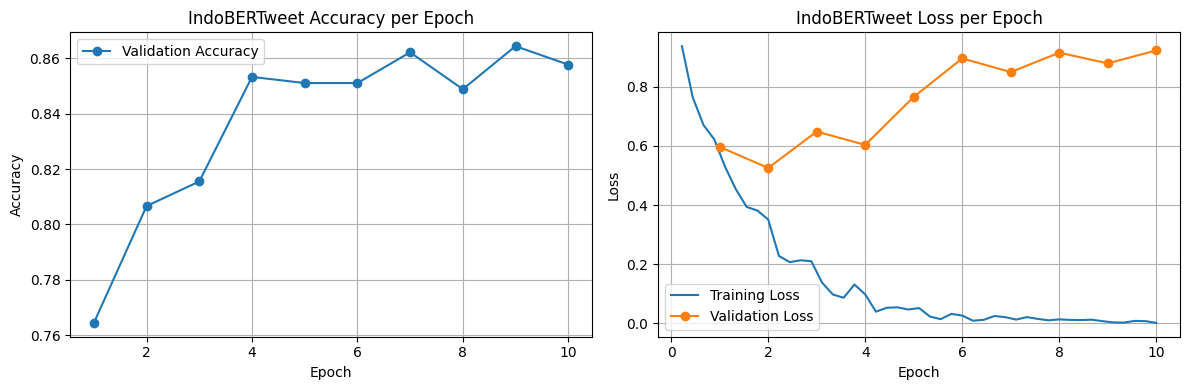

In [ ]:
log_history = trainer.state.log_history

train_epochs, train_losses = [], []
eval_epochs, eval_losses, eval_accs = [], [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_epochs.append(entry["epoch"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_epochs.append(entry["epoch"])
        eval_losses.append(entry["eval_loss"])
        eval_accs.append(entry.get("eval_accuracy"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(eval_epochs, eval_accs, label="Validation Accuracy", marker="o")
axes[0].set_title("IndoBERTweet Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(train_epochs, train_losses, label="Training Loss")
axes[1].plot(eval_epochs, eval_losses, label="Validation Loss", marker="o")
axes[1].set_title("IndoBERTweet Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 16. Evaluasi Fine-tuned IndoBERTweet

In [ ]:
def evaluate_detailed(trainer, dataset, y_true, set_name="Test"):
    predictions_output = trainer.predict(dataset)
    y_pred = np.argmax(predictions_output.predictions, axis=1)
    evaluate(y_true, y_pred, set_name)
    y_prob = torch.nn.functional.softmax(torch.tensor(predictions_output.predictions), dim=1).numpy()
    return y_pred, y_prob


_ = evaluate_detailed(trainer, valset_ft, yval_ft, "Fine-tuned IndoBERTweet - Validation")
_ = evaluate_detailed(trainer, testset_ft, ytest_ft, "Fine-tuned IndoBERTweet - Test")


Fine-tuned IndoBERTweet - Validation
Accuracy  : 0.8644
Precision : 0.8632
Recall    : 0.8644
F1-score  : 0.8636

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       150
           1       0.86      0.85      0.85       150
           2       0.82      0.79      0.81       150

    accuracy                           0.86       450
   macro avg       0.86      0.86      0.86       450
weighted avg       0.86      0.86      0.86       450

Confusion Matrix:
[[143   0   7]
 [  4 127  19]
 [ 10  21 119]]



Fine-tuned IndoBERTweet - Test
Accuracy  : 0.8600
Precision : 0.8596
Recall    : 0.8600
F1-score  : 0.8596

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       150
           1       0.86      0.83      0.84       150
           2       0.81      0.81      0.81       150

    accuracy                           0.86       450
   macro avg       0.86      0.86      0.86       450
weighted avg       0.86      0.86      0.86       450

Confusion Matrix:
[[141   1   8]
 [  5 124  21]
 [  8  20 122]]


# ENSEMBLE
## 17. Prediksi tiap model di TEST SET (semua model masih di memory, tidak perlu load ulang)

In [ ]:
print("Prediksi dari SVM...")
svm_pred = svm_model.predict(X_test_svm)
svm_prob = svm_model.predict_proba(X_test_svm)

print("Prediksi dari BiLSTM...")
bilstm_prob_raw = bilstm_model.predict(X_test_bilstm, verbose=0)
if bilstm_prob_raw.shape[1] == 1:
    bilstm_pred = (bilstm_prob_raw > 0.5).astype(int).ravel()
    bilstm_prob = np.hstack([1 - bilstm_prob_raw, bilstm_prob_raw])
else:
    bilstm_pred = np.argmax(bilstm_prob_raw, axis=1)
    bilstm_prob = bilstm_prob_raw

print("Prediksi dari Fine-tuned IndoBERTweet...")
ft_pred_output = trainer.predict(testset_ft)
ft_pred = np.argmax(ft_pred_output.predictions, axis=1)
ft_prob = torch.nn.functional.softmax(torch.tensor(ft_pred_output.predictions), dim=1).numpy()

# PENTING: ketiga model ini dievaluasi di X_test_svm / X_test_bilstm / testset_ft yang
# SEMUANYA berasal dari texts_test yang SAMA (hasil split kanonis di Cell 5), cuma beda
# jalur preprocessing -- jadi index ke-i di ketiganya merujuk ke kalimat test yang sama.
individual_preds = {"svm": svm_pred, "bilstm": bilstm_pred, "indobertweet": ft_pred}
individual_probs = {"svm": svm_prob, "bilstm": bilstm_prob, "indobertweet": ft_prob}
y_test_final = ytest_svm  # sama saja dengan ytest_bilstm / ytest_ft (semua dari y_test asli)

Prediksi dari SVM...
Prediksi dari BiLSTM...
Prediksi dari Fine-tuned IndoBERTweet...


## 18. Ensemble: Hard Voting & Soft Voting

In [ ]:
def ensemble_hard_voting(individual_preds, num_classes, weights=None):
    if weights is None:
        weights = {"svm": 1.0, "bilstm": 1.0, "indobertweet": 1.0}
    n_samples = len(next(iter(individual_preds.values())))
    vote_matrix = np.zeros((n_samples, num_classes))
    for name, pred in individual_preds.items():
        for i, p in enumerate(pred):
            vote_matrix[i, p] += weights[name]
    return np.argmax(vote_matrix, axis=1)


def ensemble_soft_voting(individual_probs, num_classes, weights=None):
    if weights is None:
        weights = {"svm": 1.0, "bilstm": 1.0, "indobertweet": 1.0}
    n_samples = len(next(iter(individual_probs.values())))
    combined_prob = np.zeros((n_samples, num_classes))
    for name, prob in individual_probs.items():
        combined_prob += weights[name] * prob
    return np.argmax(combined_prob, axis=1), combined_prob


hard_pred = ensemble_hard_voting(individual_preds, num_classes, weights=MODEL_WEIGHTS)
soft_pred, combined_prob = ensemble_soft_voting(individual_probs, num_classes, weights=MODEL_WEIGHTS)

## 19. Perbandingan hasil: tiap model individual vs ensemble

In [ ]:
for name, pred in individual_preds.items():
    evaluate(y_test_final, pred, set_name=f"Model individual: {name}")

evaluate(y_test_final, hard_pred, set_name="ENSEMBLE (Hard Voting)")
evaluate(y_test_final, soft_pred, set_name="ENSEMBLE (Soft Voting)")


Model individual: svm
Accuracy  : 0.8133
Precision : 0.8283
Recall    : 0.8133
F1-score  : 0.8161

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89       150
           1       0.86      0.74      0.80       150
           2       0.69      0.85      0.76       150

    accuracy                           0.81       450
   macro avg       0.83      0.81      0.82       450
weighted avg       0.83      0.81      0.82       450

Confusion Matrix:
[[128   1  21]
 [  3 111  36]
 [  6  17 127]]

Model individual: bilstm
Accuracy  : 0.8267
Precision : 0.8263
Recall    : 0.8267
F1-score  : 0.8263

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       150
           1       0.82      0.78      0.80       150
           2       0.76      0.78      0.77       150

    accuracy                           0.83       450
   macro avg       0.83      0.83 

{'accuracy': 0.8733333333333333,
 'precision': 0.8751986480005154,
 'recall': 0.8733333333333333,
 'f1': 0.8733206374004316}

## 20. Simpan semua model & hasil

In [ ]:
joblib.dump(svm_model, "svm_word2vec_model.joblib")
w2v_model.save("word2vec_model.model")
bilstm_model.save("bilstm_indobertweet_model.keras")
trainer.save_model(FT_OUTPUT_DIR)
ft_tokenizer.save_pretrained(FT_OUTPUT_DIR)

results_df = pd.DataFrame({
    "text": texts_test,
    "y_true": y_test_final,
    "pred_svm": individual_preds["svm"],
    "pred_bilstm": individual_preds["bilstm"],
    "pred_indobertweet": individual_preds["indobertweet"],
    "pred_ensemble_hard": hard_pred,
    "pred_ensemble_soft": soft_pred,
})
results_df.to_csv("ensemble_predictions.csv", index=False)
print("Semua model & hasil prediksi tersimpan.")
results_df.head()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Semua model & hasil prediksi tersimpan.


,text,y_true,pred_svm,pred_bilstm,pred_indobertweet,pred_ensemble_hard,pred_ensemble_soft
0,"[USER] [USER] [USER] Ini bukan cegil ya kak, c...",1,1,1,1,1,1
1,"[USER] Bener, wanita melihat ayahnya(kalau bai...",2,0,2,2,2,2
2,[USER] [USER] Udah ketahuan semenjak pacaran D...,0,0,0,0,0,0
3,Kata gwe ka [USER] harus di kasih reward sebag...,2,2,2,2,2,2
4,5 HARI LAGI! Jangan lewatkan KKR BAKTI WANITA ...,2,2,2,2,2,2


In [ ]:
!zip -r training_260911.zip training_260911

  adding: training_260911/ (stored 0%)
  adding: training_260911/indobertweet_finetuned/ (stored 0%)
  adding: training_260911/indobertweet_finetuned/training_args.bin (deflated 53%)
  adding: training_260911/indobertweet_finetuned/config.json (deflated 54%)
  adding: training_260911/indobertweet_finetuned/tokenizer_config.json (deflated 43%)
  adding: training_260911/indobertweet_finetuned/model.safetensors (deflated 7%)
  adding: training_260911/indobertweet_finetuned/tokenizer.json (deflated 71%)
  adding: training_260911/ensemble_predictions.csv (deflated 59%)
  adding: training_260911/bilstm_indobertweet_model.keras (deflated 7%)
  adding: training_260911/svm_training/ (stored 0%)
  adding: training_260911/svm_training/svm_word2vec_model.joblib (deflated 46%)
  adding: training_260911/svm_training/word2vec_model.model (deflated 9%)


### Bersihkan checkpoint intermediate


In [ ]:
import shutil, glob

for ckpt_dir in glob.glob(f"{FT_OUTPUT_DIR}/checkpoint-*"):
    shutil.rmtree(ckpt_dir)
    print(f"Dihapus: {ckpt_dir}")

print("\nIsi folder setelah dibersihkan:")
for f in sorted(glob.glob(f"{FT_OUTPUT_DIR}/*")):
    print(f)

Dihapus: ./indobertweet_finetuned/checkpoint-2250
Dihapus: ./indobertweet_finetuned/checkpoint-2025

Isi folder setelah dibersihkan:
./indobertweet_finetuned/config.json
./indobertweet_finetuned/model.safetensors
./indobertweet_finetuned/tokenizer.json
./indobertweet_finetuned/tokenizer_config.json
./indobertweet_finetuned/training_args.bin
